# 07 — Master Data Feature Selection

## Workflow

```
Step  Description
────  ──────────────────────────────────────────────────────────────────
  1   Load gold dataset          full discovery extraction
  2   Column inventory & audit   classify columns; confirm zero nulls
  3   Feature state init         mutable scope list + filter log
  4   Dimensionality reduction   five independently toggleable filters
      4.1  Variance              remove near-zero-variance features
      4.2  Target correlation    keep features with |r| ≥ threshold
      4.3  SelectKBest           univariate F-statistic ranking
      4.4  Tree importance       non-linear importance verification
      4.5  Redundancy removal    drop one of each highly-correlated pair
  5   Scatter validation         visual sanity check on top survivors
  6   Feature group assignment   map survivors to FEATURE_CATALOG names
  7   Reduction summary          funnel chart + final feature list
  8   Generate FEATURE_CATALOG   ready-to-paste Python code
```

### Toggle system

Each filter in Section 4 has two configuration knobs at the top of its *Apply* cell:

| Variable | Values | Effect |
|---|---|---|
| `APPLY_<FILTER>` | `True` / `False` | Include or skip this filter |
| `INPUT_<FILTER>` | `"in_scope"` / `"all_features"` | Start from current survivors or the full feature list |

`INPUT_<FILTER> = "all_features"` lets you test any single filter in isolation without cascading results from earlier steps.

All retained / dropped column names are emitted via the `feature_selection` logger at **INFO** (counts) and **DEBUG** (full name lists).

In [64]:
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression
from sklearn.ensemble import ExtraTreesRegressor
import polars as pl
import polars.selectors as cs

PROJECT_ROOT = Path().resolve().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DIR_DB_GOLD, ML_TARGET_COLUMN

# ── Structural columns — never treated as ML features ──────────────────────
STRUCTURAL_COLS   = {"silver_id", "quarter", "year", "period_enddate",
                     "BedrijfstakkenBranchesSBI2008"}
SBI_FILTER_PREFIX = "BedrijfskenmerkenSBI2008_"

# ── Visualization palette (consistent across all filter plots) ──────────────
RETAINED_COLOR = "#4472C4"   # blue   — feature survives
DROPPED_COLOR  = "#D95F02"   # orange — feature pruned

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110

# ── Logging ─────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.DEBUG,
    format="%(levelname)s — %(name)s — %(message)s",
    handlers=[logging.StreamHandler()],
    force=True,
)
logger = logging.getLogger("feature_selection")

print(f"Project root : {PROJECT_ROOT}")
print(f"Gold DB      : {DIR_DB_GOLD}")
print(f"Target       : {ML_TARGET_COLUMN}")

Project root : C:\Users\Yanni\Github\EAISI\eaisi-uwv
Gold DB      : C:\Users\Yanni\Github\EAISI\eaisi-uwv\data\3_gold\gold_data.db
Target       : Ziekteverzuimpercentage_1


---
## 1 — Load the Gold Dataset

Extract all columns from `master_data_ml_preprocessed` in discovery mode (no feature group filter).

In [65]:
from src.ml_engineering.ml_1_data_extraction import DataExtractor

extractor = DataExtractor(db_path=DIR_DB_GOLD, table_name="master_data_ml_preprocessed")
df_raw = extractor.extract(target_column=ML_TARGET_COLUMN, feature_groups=None)

print(f"Shape: {df_raw.shape[0]:,} rows \u00d7 {df_raw.shape[1]:,} columns")
df_raw.head(3)

STAGE — eaisi_uwv — ⚙️ SBI mode=all-industry (BedrijfskenmerkenSBI2008_T001081) | 119 quarterly rows
STAGE — eaisi_uwv — ✅ Extraction complete | mode=discovery | sbi=all-industry | features=398 | rows=119


Shape: 119 rows × 402 columns


,period_enddate,year,quarter,Ziekteverzuimpercentage_1,trend_index,AdemtGeenStoffenIn_24_MBG0095,AdemtGeenStoffenIn_24_MOG0095,AdemtGeenStoffenIn_24_MW00000,AdemtStoffenIn_20_MBG0095,AdemtStoffenIn_20_MOG0095,...,GewerkteUren_5_A045285,GewerkteUren_5_A045286,WerkzamePersonenSeizoengecorrigeerd_2_A045285,WerkzamePersonenSeizoengecorrigeerd_2_A045286,WerkzamePersonenSeizoengecorrigeerd_9_A045285,WerkzamePersonenSeizoengecorrigeerd_9_A045286,WerkzamePersonen_1_A045285,WerkzamePersonen_1_A045286,WerkzamePersonen_7_A045285,WerkzamePersonen_7_A045286
0,1996-03-31 00:00:00.000000,1996.0,1.0,5.5,1.0,4.0,3.7,3.9,5.5,4.5,...,216.866667,44.733333,589.733333,102.600000,0.800000,-0.066667,582.933333,102.000000,13.2,0.733333
1,1996-06-30 00:00:00.000000,1996.0,2.0,4.6,2.0,4.0,3.7,3.9,5.5,4.5,...,202.733333,46.600000,594.066667,102.600000,4.333333,0.066667,596.466667,102.733333,15.2,0.266667
2,1996-09-30 00:00:00.000000,1996.0,3.0,4.0,3.0,4.0,3.7,3.9,5.5,4.5,...,198.866667,43.866667,597.866667,102.733333,3.800000,0.266667,604.133333,102.866667,14.8,0.400000


---
## 2 — Column Inventory & Audit

Classify every column into one of four buckets, then confirm zero nulls across feature columns.

| Bucket | Description |
|---|---|
| `structural` | Date / key columns — never ML features |
| `target` | Dependent variable `Ziekteverzuimpercentage_1` |
| `sector_filter` | OHE dummies (`BedrijfskenmerkenSBI2008_*`) for sub-sector selection |
| `feature` | Genuine numeric predictors passed to the reduction pipeline |

In [66]:
structural    = [c for c in df_raw.columns if c in STRUCTURAL_COLS]
target_col    = [ML_TARGET_COLUMN]
sector_filter = [c for c in df_raw.columns if c.startswith(SBI_FILTER_PREFIX)]
feature_cols  = [
    c for c in df_raw.columns
    if c not in STRUCTURAL_COLS
    and c != ML_TARGET_COLUMN
    and not c.startswith(SBI_FILTER_PREFIX)
]

summary = pd.DataFrame({
    "Bucket":   ["structural", "target", "sector_filter (OHE)", "feature"],
    "Count":    [len(structural), len(target_col), len(sector_filter), len(feature_cols)],
    "Examples": [
        ", ".join(structural[:3]),
        ML_TARGET_COLUMN,
        ", ".join(sector_filter[:3]),
        ", ".join(feature_cols[:3]),
    ],
})
print(summary.to_string(index=False))
print(f"\nTotal ML features (excl. structural + target + sector_filter): {len(feature_cols)}")

# Null audit — master_data_ml_preprocessed is post-imputation; nulls here signal a pipeline issue
null_counts     = df_raw[feature_cols].isnull().sum()
cols_with_nulls = null_counts[null_counts > 0]
if cols_with_nulls.empty:
    print("\n\u2705  Zero nulls across all feature columns.")
else:
    print(f"\n\u26a0\ufe0f   {len(cols_with_nulls)} columns still contain nulls:")
    print(cols_with_nulls.sort_values(ascending=False).head(20))

             Bucket  Count                                                                  Examples
         structural      3                                             period_enddate, year, quarter
             target      1                                                 Ziekteverzuimpercentage_1
sector_filter (OHE)      0                                                                          
            feature    398 trend_index, AdemtGeenStoffenIn_24_MBG0095, AdemtGeenStoffenIn_24_MOG0095

Total ML features (excl. structural + target + sector_filter): 398

✅  Zero nulls across all feature columns.


---
## 3 — Feature State Initialisation

`features_in_scope` is the mutable active feature list.
Each **enabled** filter in Section 4 overwrites it with its retained set.
`filter_log` accumulates one result dict per applied filter for the Section 7 summary.

In [67]:
features_in_scope: list[str] = list(feature_cols)   # updated by each active filter
filter_log:        list[dict] = []                    # accumulates filter result dicts

print(f"Initial scope: {len(features_in_scope)} features")

Initial scope: 398 features


---
## 4 — Dimensionality Reduction

Five independently toggleable filters. Each subsection follows a consistent four-cell pattern:

1. **Markdown** — what the filter does and which parameters to tune
2. **Function definitions** — `apply_<filter>` returns a standardised result dict; `plot_<filter>` visualises it
3. **Apply cell** — set `APPLY_*` + `INPUT_*` + parameters, run the filter, update state
4. **Visualisation** — call `plot_<filter>(result_<filter>)`

Every `apply_*` function returns the same dict shape:
```python
{
    "filter":   str,           # label shown in the Section 7 funnel
    "params":   dict,          # parameters used
    "input":    list[str],     # features entering the filter
    "retained": list[str],     # features that passed
    "dropped":  list[str],     # features that were pruned
    "scores":   pd.Series | pd.DataFrame,  # raw scores for the plot
}
```

---
### 4.1 — Variance Filter

**What it does:** Drops features whose variance across all observations falls below `VAR_THRESHOLD`.
A near-zero-variance feature is essentially constant and carries no predictive signal.

**Parameters:**

| Variable | Typical range | Effect |
|---|---|---|
| `VAR_THRESHOLD` | 0.0001 – 0.01 | Higher → more features dropped |

CBS features are ratios / rates bounded in narrow ranges (e.g. 0.02–0.08).
Start low (`0.001`) and raise only if the histogram shows a clear natural gap.

In [68]:
def apply_variance_filter(feature_list, df, threshold=0.001):
    # Drop features with variance < threshold
    X        = df[feature_list]
    selector = VarianceThreshold(threshold=threshold)
    selector.fit(X)
    mask     = selector.get_support()
    retained = [c for c, keep in zip(feature_list, mask) if keep]
    dropped  = [c for c, keep in zip(feature_list, mask) if not keep]
    return {
        "filter":   "4.1  Variance",
        "params":   {"threshold": threshold},
        "input":    feature_list,
        "retained": retained,
        "dropped":  dropped,
        "scores":   X.var().rename("variance"),
    }


def plot_variance_filter(result):
    # Histogram of feature variances; drop threshold as a vertical dashed line
    scores    = result["scores"].sort_values()
    threshold = result["params"]["threshold"]
    quantile = 0.80
    clip_at   = float(scores.quantile(quantile))

    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.hist(scores[scores <= clip_at], bins=50,
            color=RETAINED_COLOR, edgecolor="white", alpha=0.85)
    ax.axvline(threshold, color=DROPPED_COLOR, linewidth=2, linestyle="--",
               label=f"threshold = {threshold}")
    ax.set_title(
        f"4.1 Variance Filter \u2014 {len(result['retained'])} retained, "
        f"{len(result['dropped'])} dropped  (input: {len(result['input'])})"
    )
    ax.set_xlabel(f"Variance (x-axis clipped at {quantile} percentile)")
    ax.set_ylabel("# Features")
    ax.legend()
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

In [69]:
# ─── CONFIGURATION ────────────────────────────────────────────────────────
APPLY_VARIANCE = True          # True → update features_in_scope
INPUT_VARIANCE = "in_scope"    # "in_scope" | "all_features"
# ─── PARAMETER ────────────────────────────────────────────────────────────
VAR_THRESHOLD  = 0.001         # ← adjust this
# ──────────────────────────────────────────────────────────────────────────

_input_var = features_in_scope if INPUT_VARIANCE == "in_scope" else feature_cols
result_var = apply_variance_filter(_input_var, df_raw, threshold=VAR_THRESHOLD)

if APPLY_VARIANCE:
    features_in_scope = result_var["retained"]
    filter_log.append(result_var)
    logger.info("%-22s  retained=%d  dropped=%d",
                result_var["filter"], len(result_var["retained"]), len(result_var["dropped"]))
    logger.debug("%-22s  retained: %s", result_var["filter"], result_var["retained"])
    logger.debug("%-22s  dropped : %s", result_var["filter"], result_var["dropped"])

print(f"APPLY: {APPLY_VARIANCE}  |  INPUT: {INPUT_VARIANCE!r}")
print(f"  Input    : {len(_input_var)}")
print(f"  Retained : {len(result_var['retained'])}")
print(f"  Dropped  : {len(result_var['dropped'])}")
print(f"  In scope : {len(features_in_scope)}")

INFO — feature_selection — 4.1  Variance           retained=398  dropped=0
DEBUG — feature_selection — 4.1  Variance           retained: ['trend_index', 'AdemtGeenStoffenIn_24_MBG0095', 'AdemtGeenStoffenIn_24_MOG0095', 'AdemtGeenStoffenIn_24_MW00000', 'AdemtStoffenIn_20_MBG0095', 'AdemtStoffenIn_20_MOG0095', 'AdemtStoffenIn_20_MW00000', 'BesmettePersonen_21_MBG0095', 'BesmettePersonen_21_MOG0095', 'BesmettePersonen_21_MW00000', 'Besmettingskans_27_MBG0095', 'Besmettingskans_27_MOG0095', 'Besmettingskans_27_MW00000', 'DoorKlanten_60_MBG0095', 'DoorKlanten_60_MOG0095', 'DoorKlanten_60_MW00000', 'DoorKlanten_62_MBG0095', 'DoorKlanten_62_MOG0095', 'DoorKlanten_62_MW00000', 'DoorKlanten_64_MBG0095', 'DoorKlanten_64_MOG0095', 'DoorKlanten_64_MW00000', 'DoorKlanten_68_MBG0095', 'DoorKlanten_68_MOG0095', 'DoorKlanten_68_MW00000', 'DoorKlanten_70_MBG0095', 'DoorKlanten_70_MOG0095', 'DoorKlanten_70_MW00000', 'DoorKlanten_72_MBG0095', 'DoorKlanten_72_MOG0095', 'DoorKlanten_72_MW00000', 'DoorLeidi

APPLY: True  |  INPUT: 'in_scope'
  Input    : 398
  Retained : 398
  Dropped  : 0
  In scope : 398


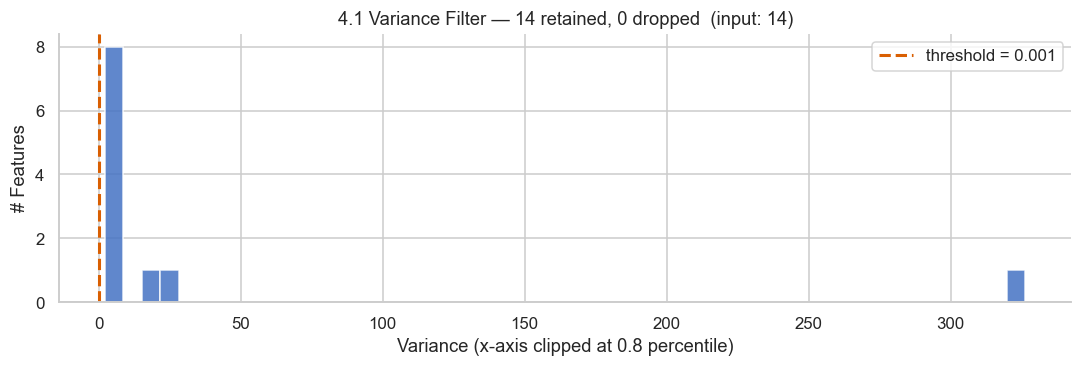

In [63]:
plot_variance_filter(result_var)

---
### 4.2 — Target Correlation Filter

**What it does:** Ranks every feature by its absolute Pearson correlation with
`Ziekteverzuimpercentage_1`. Features below `CORR_THRESHOLD` are dropped.

**Parameters:**

| Variable | Typical range | Effect |
|---|---|---|
| `CORR_THRESHOLD` | 0.02 – 0.15 | Higher → fewer, more correlated features kept |

In quarterly macro-economic aggregates, individual predictors rarely exceed r = 0.35 due to
sector heterogeneity. Stay inclusive (≤ 0.05) and let the redundancy filter remove collinear
duplicates in step 4.5.

In [40]:
def apply_correlation_filter(feature_list, df, target, threshold=0.05):
    # Rank by |Pearson r| with target; drop those below threshold
    X = df[feature_list]
    y = df[target]
    scores = (
        X.corrwith(y)
        .dropna()
        .rename("pearson_r")
        .to_frame()
        .assign(abs_r=lambda d: d["pearson_r"].abs())
        .sort_values("abs_r", ascending=False)
    )
    retained = scores[scores["abs_r"] >= threshold].index.tolist()
    dropped  = scores[scores["abs_r"] <  threshold].index.tolist()
    return {
        "filter":   "4.2  Target Correlation",
        "params":   {"threshold": threshold, "target": target},
        "input":    feature_list,
        "retained": retained,
        "dropped":  dropped,
        "scores":   scores,
    }


def plot_corr_n_strongest(df: pd.DataFrame, y: str, n: int = 10):
    """
    Lower-triangle heatmap of the n features most correlated with target y.
    Uses Polars internally for fast correlation computation.
    """
    df_pl = pl.from_pandas(df).select(cs.numeric())
    df_pl = df_pl.with_columns(pl.all().cast(pl.Float64, strict=False))
    if y not in df_pl.columns:
        raise KeyError(f"Target column {y!r} not found.")
    corr_matrix = df_pl.corr()
    corr_with_y = (
        pl.DataFrame({"feature": corr_matrix.columns, "corr": corr_matrix[y].to_list()})
        .drop_nans()
        .filter(pl.col("feature") != y)
        .with_columns(pl.col("corr").abs().alias("abs_corr"))
        .sort("abs_corr", descending=True)
        .head(n)
    )
    cols_to_plot = corr_with_y.get_column("feature").to_list() + [y]
    corr_pd      = df_pl.select(cols_to_plot).corr().to_pandas()
    corr_pd.index = corr_pd.columns
    mask          = np.triu(np.ones_like(corr_pd, dtype=bool))

    fig, ax = plt.subplots(figsize=(11.7, 8.27))
    sns.heatmap(corr_pd, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
                vmin=-1, vmax=1, center=0, linewidths=0.5,
                annot_kws={"size": 7}, ax=ax)
    ax.set_title(f'Top {n} Features Most Correlated with "{y}"', pad=12)
    plt.tight_layout()
    plt.show()


def plot_correlation_filter(result, top_n=15):
    # Two outputs: |r| histogram and top-N feature heatmap
    scores    = result["scores"]
    threshold = result["params"]["threshold"]
    target    = result["params"]["target"]

    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.hist(scores["abs_r"], bins=40, color=RETAINED_COLOR, edgecolor="white", alpha=0.85)
    ax.axvline(threshold, color=DROPPED_COLOR, linewidth=2, linestyle="--",
               label=f"threshold = {threshold}")
    ax.set_title(
        f"4.2 Target Correlation \u2014 {len(result['retained'])} retained, "
        f"{len(result['dropped'])} dropped  (input: {len(result['input'])})"
    )
    ax.set_xlabel("|Pearson r| with target")
    ax.set_ylabel("# Features")
    ax.legend()
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

    plot_corr_n_strongest(
        df_raw[result["input"] + [target]],
        y=target,
        n=min(top_n, len(result["retained"])),
    )

In [41]:
# ─── CONFIGURATION ────────────────────────────────────────────────────────
APPLY_CORRELATION = True          # True → update features_in_scope
INPUT_CORRELATION = "in_scope"    # "in_scope" | "all_features"
# ─── PARAMETER ────────────────────────────────────────────────────────────
CORR_THRESHOLD    = 0.05          # ← adjust this
# ──────────────────────────────────────────────────────────────────────────

_input_corr = features_in_scope if INPUT_CORRELATION == "in_scope" else feature_cols
result_corr = apply_correlation_filter(
    _input_corr, df_raw, target=ML_TARGET_COLUMN, threshold=CORR_THRESHOLD
)

if APPLY_CORRELATION:
    features_in_scope = result_corr["retained"]
    filter_log.append(result_corr)
    logger.info("%-22s  retained=%d  dropped=%d",
                result_corr["filter"], len(result_corr["retained"]), len(result_corr["dropped"]))
    logger.debug("%-22s  retained: %s", result_corr["filter"], result_corr["retained"])
    logger.debug("%-22s  dropped : %s", result_corr["filter"], result_corr["dropped"])

print(f"APPLY: {APPLY_CORRELATION}  |  INPUT: {INPUT_CORRELATION!r}")
print(f"  Input    : {len(_input_corr)}")
print(f"  Retained : {len(result_corr['retained'])}")
print(f"  Dropped  : {len(result_corr['dropped'])}")
print(f"  In scope : {len(features_in_scope)}")

INFO — feature_selection — 4.2  Target Correlation  retained=384  dropped=14
DEBUG — feature_selection — 4.2  Target Correlation  retained: ['GewerkteUren_3_A045285_4000', 'BeloningVanWerknemers_5', 'Loonkosten_7', 'WerkzamePersonen_6_A045285_3000', 'Banen_7_A045285_3000', 'GewerkteUren_3_A045285_3000', 'Banen_7_A045285_4000', 'Lonen_6', 'WerkzamePersonen_6_A045285_4000', 'LoonkostenPerGewerktUur_19', 'GewerkteUren_8_A045285_4000', 'Banen_2_A045285_4000', 'WerkzamePersonen_1_A045285_4000', 'Arbeidsjaren_3_3000_A045285', 'GeenRepeterendeBewegingTijdensWerk_33_MBG0095', 'Banen_7_A045286_3000', 'ErgSnelWerken_2_MBG0095', 'WerkzamePersonen_1_A045285_3000', 'NietHeelVeelWerkDoen_7_MOG0095', 'GeenOngemakkelijkeWerkhouding_32_MW00000', 'NietRegelmatigHardPraten_12_MBG0095', 'KanNietWerktempoBepalen_40_MOG0095', 'KanNietWerktijdenBepalen_43_MW00000', 'WerktempoBepalen_47_MW00000', 'Banen_2_A045286_4000', 'NietHeelVeelWerkDoen_7_MBG0095', 'KanNietWerktempoBepalen_40_MW00000', 'NietExtraHardWerk

APPLY: True  |  INPUT: 'in_scope'
  Input    : 398
  Retained : 384
  Dropped  : 14
  In scope : 384


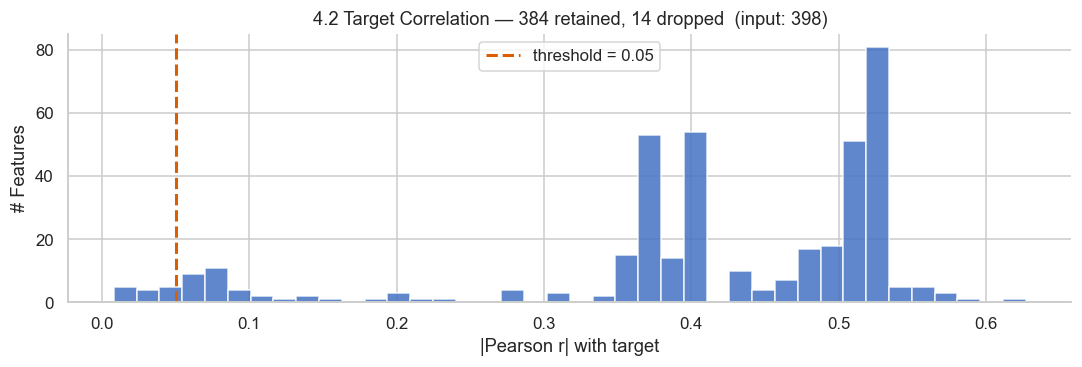

DEBUG — matplotlib.colorbar — locator: <matplotlib.ticker.AutoLocator object at 0x00000299E60CCC70>


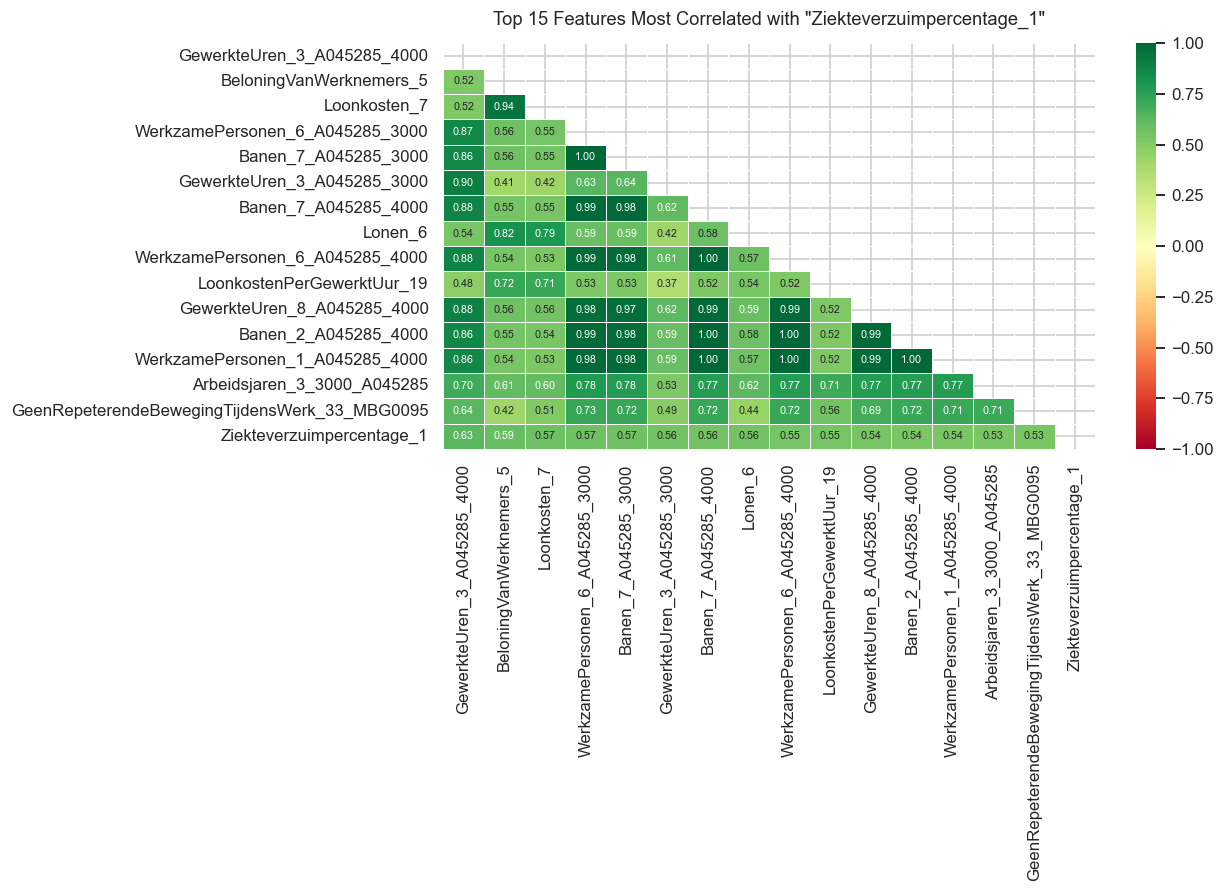

In [42]:
plot_correlation_filter(result_corr)

---
### 4.3 — SelectKBest (F-statistic)

**What it does:** Scores every feature using the **F-statistic for regression** (`f_regression`).
This is the univariate parametric complement to the Pearson |r| ranking: it assigns an F-score
and p-value to each feature's linear relationship with the target, then keeps the top
`K_BEST_RATIO × 100 %` of features.

**Parameters:**

| Variable | Typical range | Effect |
|---|---|---|
| `K_BEST_RATIO` | 0.5 – 0.9 | Fraction of input features to retain |

> **No leakage note:** Fitted on the full historical dataset for exploratory purposes only.
> In production, feature selection runs strictly inside each CV fold's training split.

In [43]:
def apply_kbest_filter(feature_list, df, target, ratio=0.70):
    # Score with SelectKBest (F-statistic); keep top ratio x 100 %
    X = df[feature_list]
    y = df[target]
    k = max(1, int(len(feature_list) * ratio))
    selector = SelectKBest(score_func=f_regression, k=k)
    selector.fit(X, y)
    scores = (
        pd.DataFrame(
            {"f_score": selector.scores_, "p_value": selector.pvalues_},
            index=feature_list,
        )
        .sort_values("f_score", ascending=False)
    )
    mask     = selector.get_support()
    retained = [c for c, keep in zip(feature_list, mask) if keep]
    dropped  = [c for c, keep in zip(feature_list, mask) if not keep]
    return {
        "filter":   "4.3  SelectKBest",
        "params":   {"ratio": ratio, "k": k},
        "input":    feature_list,
        "retained": retained,
        "dropped":  dropped,
        "scores":   scores,
    }


def plot_kbest_filter(result, top_n=20):
    # Horizontal bar chart of top-N F-scores; dashed cut-off line at k-th score
    scores = result["scores"]
    k      = result["params"]["k"]
    ratio  = result["params"]["ratio"]
    n_plot = min(top_n, len(scores))
    plot_data = scores.head(n_plot)
    cutoff_f  = float(scores.iloc[k - 1]["f_score"]) if k <= len(scores) else 0.0
    colors    = [
        RETAINED_COLOR if f >= cutoff_f else DROPPED_COLOR
        for f in plot_data["f_score"]
    ]

    fig, ax = plt.subplots(figsize=(10, max(4, n_plot * 0.3)))
    ax.barh(plot_data.index[::-1], plot_data["f_score"].iloc[::-1],
            color=colors[::-1], edgecolor="white", alpha=0.85)
    ax.axvline(cutoff_f, color=DROPPED_COLOR, linewidth=1.5, linestyle="--",
               label=f"cut-off F = {cutoff_f:.1f}  (top {int(ratio * 100)} %)")
    ax.set_xlabel("F-score  (f_regression)")
    ax.set_title(
        f"4.3 SelectKBest \u2014 {len(result['retained'])} retained, "
        f"{len(result['dropped'])} dropped  (k = {k})"
    )
    ax.legend()
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

In [44]:
# ─── CONFIGURATION ────────────────────────────────────────────────────────
APPLY_KBEST = True          # True → update features_in_scope
INPUT_KBEST = "in_scope"    # "in_scope" | "all_features"
# ─── PARAMETER ────────────────────────────────────────────────────────────
K_BEST_RATIO = 0.70         # ← adjust this
# ──────────────────────────────────────────────────────────────────────────

_input_kbest = features_in_scope if INPUT_KBEST == "in_scope" else feature_cols
result_kbest = apply_kbest_filter(
    _input_kbest, df_raw, target=ML_TARGET_COLUMN, ratio=K_BEST_RATIO
)

if APPLY_KBEST:
    features_in_scope = result_kbest["retained"]
    filter_log.append(result_kbest)
    logger.info("%-22s  retained=%d  dropped=%d",
                result_kbest["filter"], len(result_kbest["retained"]), len(result_kbest["dropped"]))
    logger.debug("%-22s  retained: %s", result_kbest["filter"], result_kbest["retained"])
    logger.debug("%-22s  dropped : %s", result_kbest["filter"], result_kbest["dropped"])

print(f"APPLY: {APPLY_KBEST}  |  INPUT: {INPUT_KBEST!r}")
print(f"  Input    : {len(_input_kbest)}")
print(f"  Retained : {len(result_kbest['retained'])}")
print(f"  Dropped  : {len(result_kbest['dropped'])}")
print(f"  In scope : {len(features_in_scope)}")

INFO — feature_selection — 4.3  SelectKBest        retained=268  dropped=116
DEBUG — feature_selection — 4.3  SelectKBest        retained: ['GewerkteUren_3_A045285_4000', 'BeloningVanWerknemers_5', 'Loonkosten_7', 'WerkzamePersonen_6_A045285_3000', 'Banen_7_A045285_3000', 'GewerkteUren_3_A045285_3000', 'Banen_7_A045285_4000', 'Lonen_6', 'WerkzamePersonen_6_A045285_4000', 'LoonkostenPerGewerktUur_19', 'GewerkteUren_8_A045285_4000', 'Banen_2_A045285_4000', 'WerkzamePersonen_1_A045285_4000', 'Arbeidsjaren_3_3000_A045285', 'GeenRepeterendeBewegingTijdensWerk_33_MBG0095', 'Banen_7_A045286_3000', 'ErgSnelWerken_2_MBG0095', 'WerkzamePersonen_1_A045285_3000', 'NietHeelVeelWerkDoen_7_MOG0095', 'GeenOngemakkelijkeWerkhouding_32_MW00000', 'NietRegelmatigHardPraten_12_MBG0095', 'KanNietWerktempoBepalen_40_MOG0095', 'KanNietWerktijdenBepalen_43_MW00000', 'WerktempoBepalen_47_MW00000', 'Banen_2_A045286_4000', 'NietHeelVeelWerkDoen_7_MBG0095', 'KanNietWerktempoBepalen_40_MW00000', 'NietExtraHardWerke

APPLY: True  |  INPUT: 'in_scope'
  Input    : 384
  Retained : 268
  Dropped  : 116
  In scope : 268


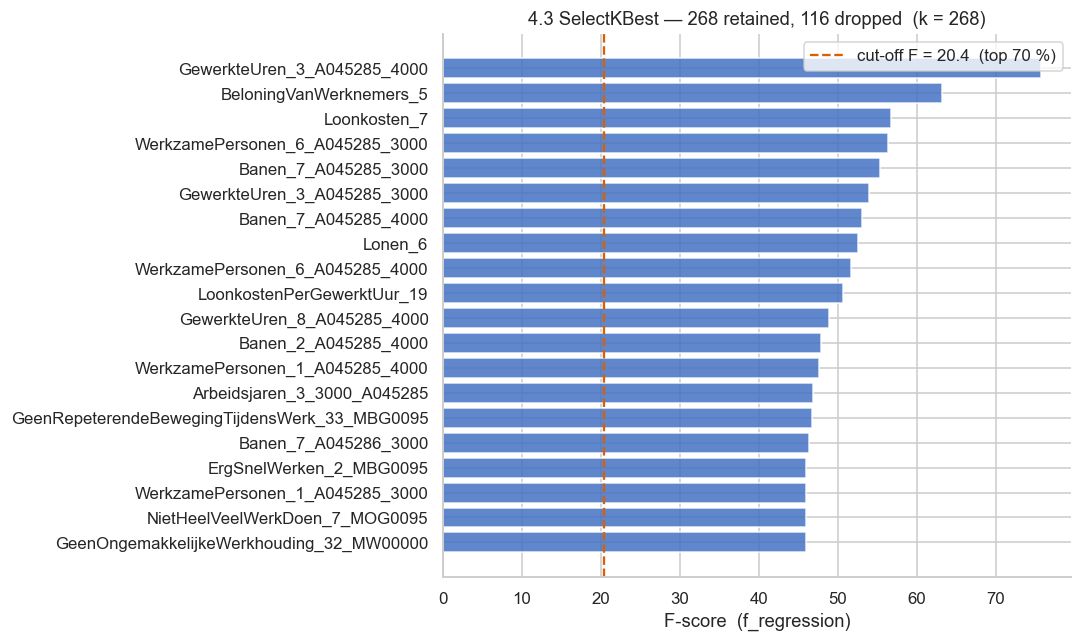

In [45]:
plot_kbest_filter(result_kbest)

---
### 4.4 — Tree-Based Feature Importance

**What it does:** Fits an `ExtraTreesRegressor` and uses `feature_importances_` (mean decrease
in impurity) as a non-linear, non-parametric score. Features below `TREE_THRESHOLD` are dropped.

The default threshold `1 / n` is the uniform-prior baseline: a feature contributing less
than chance provides no useful signal.

**Parameters:**

| Variable | Typical range | Effect |
|---|---|---|
| `TREE_THRESHOLD` | `None` (= 1/n), 0.001 – 0.01 | Higher → more features dropped |
| `N_ESTIMATORS` | 100 – 500 | More trees → more stable importances, slower |

> **No leakage note:** Fitted on the full dataset for exploratory purposes only.
> In production, this selection runs inside each CV fold's training split.

In [46]:
def apply_tree_filter(feature_list, df, target, threshold=None, n_estimators=300):
    # Fit ExtraTreesRegressor; drop features with importance < threshold (default: 1/n)
    X = df[feature_list]
    y = df[target]
    n = len(feature_list)
    if threshold is None:
        threshold = 1.0 / n
    tree = ExtraTreesRegressor(n_estimators=n_estimators, random_state=42, n_jobs=-1)
    tree.fit(X, y)
    scores = (
        pd.DataFrame({"importance": tree.feature_importances_}, index=feature_list)
        .sort_values("importance", ascending=False)
    )
    mask     = tree.feature_importances_ >= threshold
    retained = [c for c, keep in zip(feature_list, mask) if keep]
    dropped  = [c for c, keep in zip(feature_list, mask) if not keep]
    return {
        "filter":   "4.4  Tree Importance",
        "params":   {"threshold": threshold, "n_estimators": n_estimators},
        "input":    feature_list,
        "retained": retained,
        "dropped":  dropped,
        "scores":   scores,
    }


def plot_tree_filter(result):
    # Horizontal bar chart of all importances; bars below threshold in orange
    scores    = result["scores"]
    threshold = result["params"]["threshold"]
    colors    = [
        RETAINED_COLOR if imp >= threshold else DROPPED_COLOR
        for imp in scores["importance"]
    ]

    fig, ax = plt.subplots(figsize=(10, max(4, len(scores) * 0.22)))
    ax.barh(scores.index[::-1], scores["importance"].iloc[::-1],
            color=colors[::-1], edgecolor="white", alpha=0.85)
    ax.axvline(threshold, color=DROPPED_COLOR, linewidth=1.5, linestyle="--",
               label=f"threshold = {threshold:.4f}  (1/n)")
    ax.set_xlabel("Mean Decrease in Impurity")
    ax.set_title(
        f"4.4 Tree Importance \u2014 {len(result['retained'])} retained, "
        f"{len(result['dropped'])} dropped"
    )
    ax.legend()
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

In [47]:
# ─── CONFIGURATION ────────────────────────────────────────────────────────
APPLY_TREE = True          # True → update features_in_scope
INPUT_TREE = "in_scope"    # "in_scope" | "all_features"
# ─── PARAMETERS ───────────────────────────────────────────────────────────
N_ESTIMATORS   = 300       # ← adjust this
TREE_THRESHOLD = None      # ← None = 1/n (uniform prior); or a float, e.g. 0.003
# ──────────────────────────────────────────────────────────────────────────

_input_tree = features_in_scope if INPUT_TREE == "in_scope" else feature_cols
result_tree = apply_tree_filter(
    _input_tree, df_raw, target=ML_TARGET_COLUMN,
    threshold=TREE_THRESHOLD, n_estimators=N_ESTIMATORS
)

if APPLY_TREE:
    features_in_scope = result_tree["retained"]
    filter_log.append(result_tree)
    logger.info("%-22s  retained=%d  dropped=%d",
                result_tree["filter"], len(result_tree["retained"]), len(result_tree["dropped"]))
    logger.debug("%-22s  retained: %s", result_tree["filter"], result_tree["retained"])
    logger.debug("%-22s  dropped : %s", result_tree["filter"], result_tree["dropped"])

print(f"APPLY: {APPLY_TREE}  |  INPUT: {INPUT_TREE!r}")
print(f"  Input    : {len(_input_tree)}")
print(f"  Retained : {len(result_tree['retained'])}")
print(f"  Dropped  : {len(result_tree['dropped'])}")
print(f"  In scope : {len(features_in_scope)}")

INFO — feature_selection — 4.4  Tree Importance    retained=36  dropped=232
DEBUG — feature_selection — 4.4  Tree Importance    retained: ['GewerkteUren_3_A045285_4000', 'BeloningVanWerknemers_5', 'Loonkosten_7', 'WerkzamePersonen_6_A045285_3000', 'Banen_7_A045285_3000', 'GewerkteUren_3_A045285_3000', 'Banen_7_A045285_4000', 'Lonen_6', 'WerkzamePersonen_6_A045285_4000', 'LoonkostenPerGewerktUur_19', 'GewerkteUren_8_A045285_4000', 'Banen_2_A045285_4000', 'WerkzamePersonen_1_A045285_4000', 'Arbeidsjaren_3_3000_A045285', 'Banen_7_A045286_3000', 'WerkzamePersonen_1_A045285_3000', 'Banen_2_A045286_4000', 'Banen_2_A045285_3000', 'Banen_2_A045286_3000', 'WerkzamePersonen_6_A045286_4000', 'WerkzamePersonen_1_A045286_4000', 'WerkzamePersonen_6_A045286_3000', 'BeloningPerArbeidsjaar_14', 'WerkzamePersonen_1_A045286_3000', 'LoonkostenPerArbeidsjaar_16', 'GewerkteUrenPerWerkzamePersoon_4_A045285_4000', 'GewerkteUrenPerBaan_5_A045285_4000', 'Mannen_31', 'GewerkteUren_3_A045286_4000', 'GewerkteUrenP

APPLY: True  |  INPUT: 'in_scope'
  Input    : 268
  Retained : 36
  Dropped  : 232
  In scope : 36


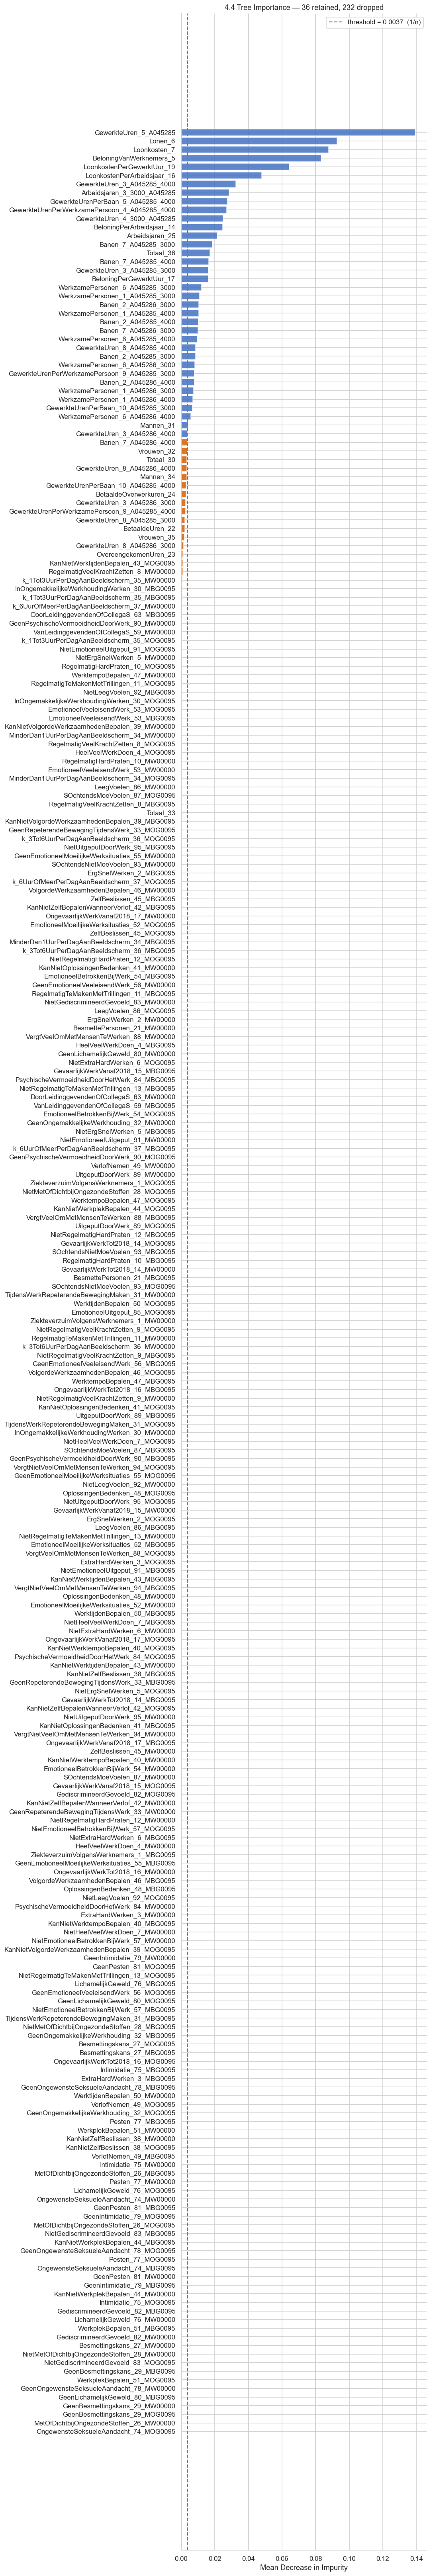

In [48]:
plot_tree_filter(result_tree)

---
### 4.5 — Redundancy Removal (Inter-Feature Correlation)

**What it does:** For each pair of features with |inter-feature r| ≥ `REDUNDANCY_THRESHOLD`,
drops the one with the *lower* absolute correlation with the target. This removes collinear
duplicates that add nothing beyond what the stronger partner already captures.

**Parameters:**

| Variable | Typical range | Effect |
|---|---|---|
| `REDUNDANCY_THRESHOLD` | 0.80 – 0.95 | Lower → more aggressive duplicate removal |

In [49]:
def apply_redundancy_filter(feature_list, df, target, threshold=0.90):
    # Drop one of each pair with |inter-feature r| >= threshold; keep the one with higher |r| vs target
    X = df[feature_list]
    y = df[target]

    target_corr = (
        X.corrwith(y).dropna()
        .rename("pearson_r").to_frame()
        .assign(abs_r=lambda d: d["pearson_r"].abs())
    )
    corr_matrix = X.corr().abs()
    upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = set()
    for col in upper.columns:
        partners = upper.index[upper[col] >= threshold].tolist()
        for partner in partners:
            r_col     = target_corr.loc[col,     "abs_r"] if col     in target_corr.index else 0
            r_partner = target_corr.loc[partner, "abs_r"] if partner in target_corr.index else 0
            to_drop.add(col if r_col < r_partner else partner)

    retained = [c for c in feature_list if c not in to_drop]
    dropped  = sorted(to_drop)
    return {
        "filter":   "4.5  Redundancy",
        "params":   {"threshold": threshold},
        "input":    feature_list,
        "retained": retained,
        "dropped":  dropped,
        "scores":   corr_matrix,
    }


def plot_redundancy_filter(result):
    # Lower-triangle heatmap of surviving feature inter-correlations
    retained  = result["retained"]
    threshold = result["params"]["threshold"]
    n         = len(retained)

    if n > 60:
        print(f"{n} features — heatmap skipped (too dense). Lower REDUNDANCY_THRESHOLD to reduce further.")
        return

    df_pl   = pl.from_pandas(df_raw[retained]).with_columns(pl.all().cast(pl.Float64, strict=False))
    corr_pd = df_pl.corr().to_pandas()
    corr_pd.index = corr_pd.columns
    mask    = np.triu(np.ones_like(corr_pd, dtype=bool))
    fig_w   = max(10, n * 0.35)

    fig, ax = plt.subplots(figsize=(fig_w, fig_w * 0.85))
    sns.heatmap(corr_pd, mask=mask, annot=(n <= 20), fmt=".2f",
                cmap="RdYlGn", vmin=-1, vmax=1, center=0,
                linewidths=0.5, annot_kws={"size": 7},
                cbar_kws={"shrink": 0.6}, ax=ax)
    ax.set_title(
        f"4.5 Redundancy \u2014 {len(result['retained'])} retained, "
        f"{len(result['dropped'])} dropped  (|r| \u2265 {threshold})", pad=12
    )
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

In [50]:
# ─── CONFIGURATION ────────────────────────────────────────────────────────
APPLY_REDUNDANCY = True          # True → update features_in_scope
INPUT_REDUNDANCY = "in_scope"    # "in_scope" | "all_features"
# ─── PARAMETER ────────────────────────────────────────────────────────────
REDUNDANCY_THRESHOLD = 0.90      # ← adjust this
# ──────────────────────────────────────────────────────────────────────────

_input_red = features_in_scope if INPUT_REDUNDANCY == "in_scope" else feature_cols
result_red = apply_redundancy_filter(
    _input_red, df_raw, target=ML_TARGET_COLUMN, threshold=REDUNDANCY_THRESHOLD
)

if APPLY_REDUNDANCY:
    features_in_scope = result_red["retained"]
    filter_log.append(result_red)
    logger.info("%-22s  retained=%d  dropped=%d",
                result_red["filter"], len(result_red["retained"]), len(result_red["dropped"]))
    logger.debug("%-22s  retained: %s", result_red["filter"], result_red["retained"])
    logger.debug("%-22s  dropped : %s", result_red["filter"], result_red["dropped"])

print(f"APPLY: {APPLY_REDUNDANCY}  |  INPUT: {INPUT_REDUNDANCY!r}")
print(f"  Input    : {len(_input_red)}")
print(f"  Retained : {len(result_red['retained'])}")
print(f"  Dropped  : {len(result_red['dropped'])}")
print(f"  In scope : {len(features_in_scope)}")

INFO — feature_selection — 4.5  Redundancy         retained=14  dropped=22
DEBUG — feature_selection — 4.5  Redundancy         retained: ['GewerkteUren_3_A045285_4000', 'BeloningVanWerknemers_5', 'WerkzamePersonen_6_A045285_3000', 'Lonen_6', 'LoonkostenPerGewerktUur_19', 'Arbeidsjaren_3_3000_A045285', 'BeloningPerArbeidsjaar_14', 'LoonkostenPerArbeidsjaar_16', 'Mannen_31', 'GewerkteUren_3_A045286_4000', 'GewerkteUrenPerWerkzamePersoon_9_A045285_3000', 'BeloningPerGewerktUur_17', 'Totaal_36', 'GewerkteUren_5_A045285']
DEBUG — feature_selection — 4.5  Redundancy         dropped : ['Arbeidsjaren_25', 'Banen_2_A045285_3000', 'Banen_2_A045285_4000', 'Banen_2_A045286_3000', 'Banen_2_A045286_4000', 'Banen_7_A045285_3000', 'Banen_7_A045285_4000', 'Banen_7_A045286_3000', 'GewerkteUrenPerBaan_10_A045285_3000', 'GewerkteUrenPerBaan_5_A045285_4000', 'GewerkteUrenPerWerkzamePersoon_4_A045285_4000', 'GewerkteUren_3_A045285_3000', 'GewerkteUren_4_3000_A045285', 'GewerkteUren_8_A045285_4000', 'Loonkos

APPLY: True  |  INPUT: 'in_scope'
  Input    : 36
  Retained : 14
  Dropped  : 22
  In scope : 14


DEBUG — matplotlib.colorbar — locator: <matplotlib.ticker.AutoLocator object at 0x00000299EB01C160>


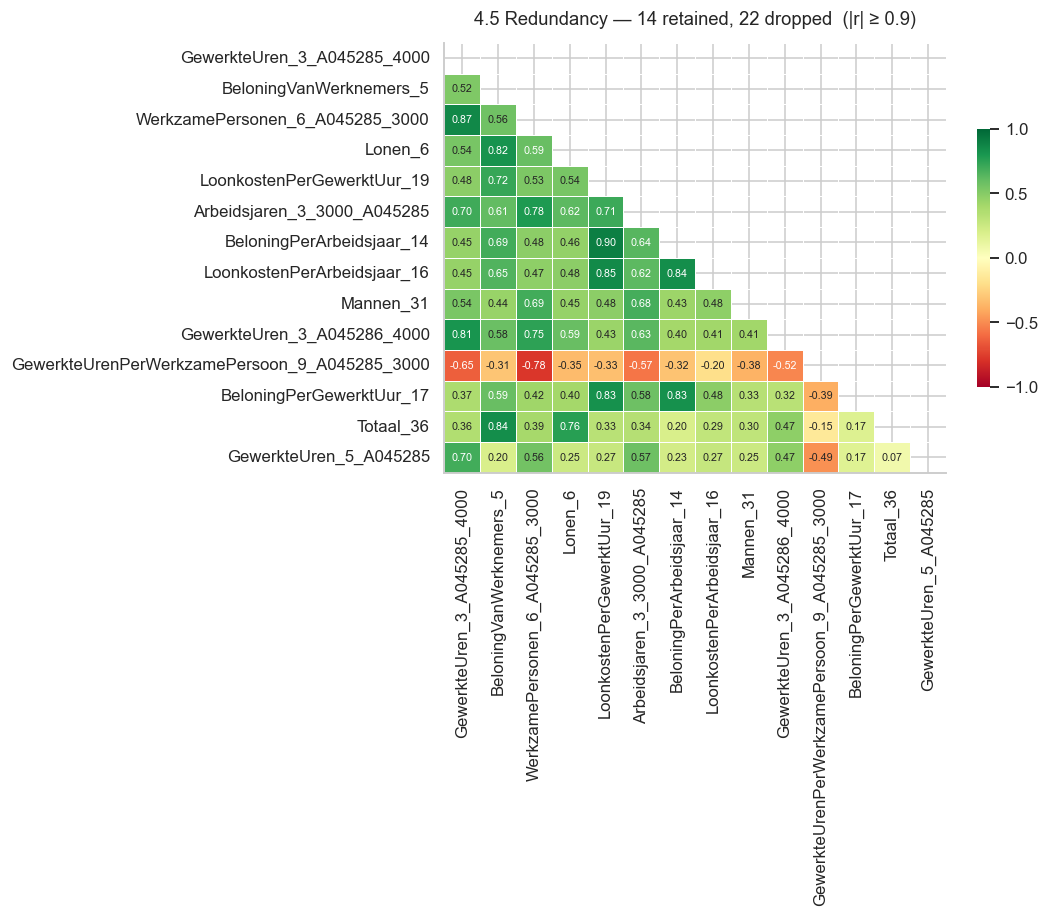

In [51]:
plot_redundancy_filter(result_red)

---
## 5 — Scatter Validation

Quick visual sanity check: does the relationship between each top survivor and the target
look sensible? Adjust `SCATTER_TOP_N` to show more or fewer panels.

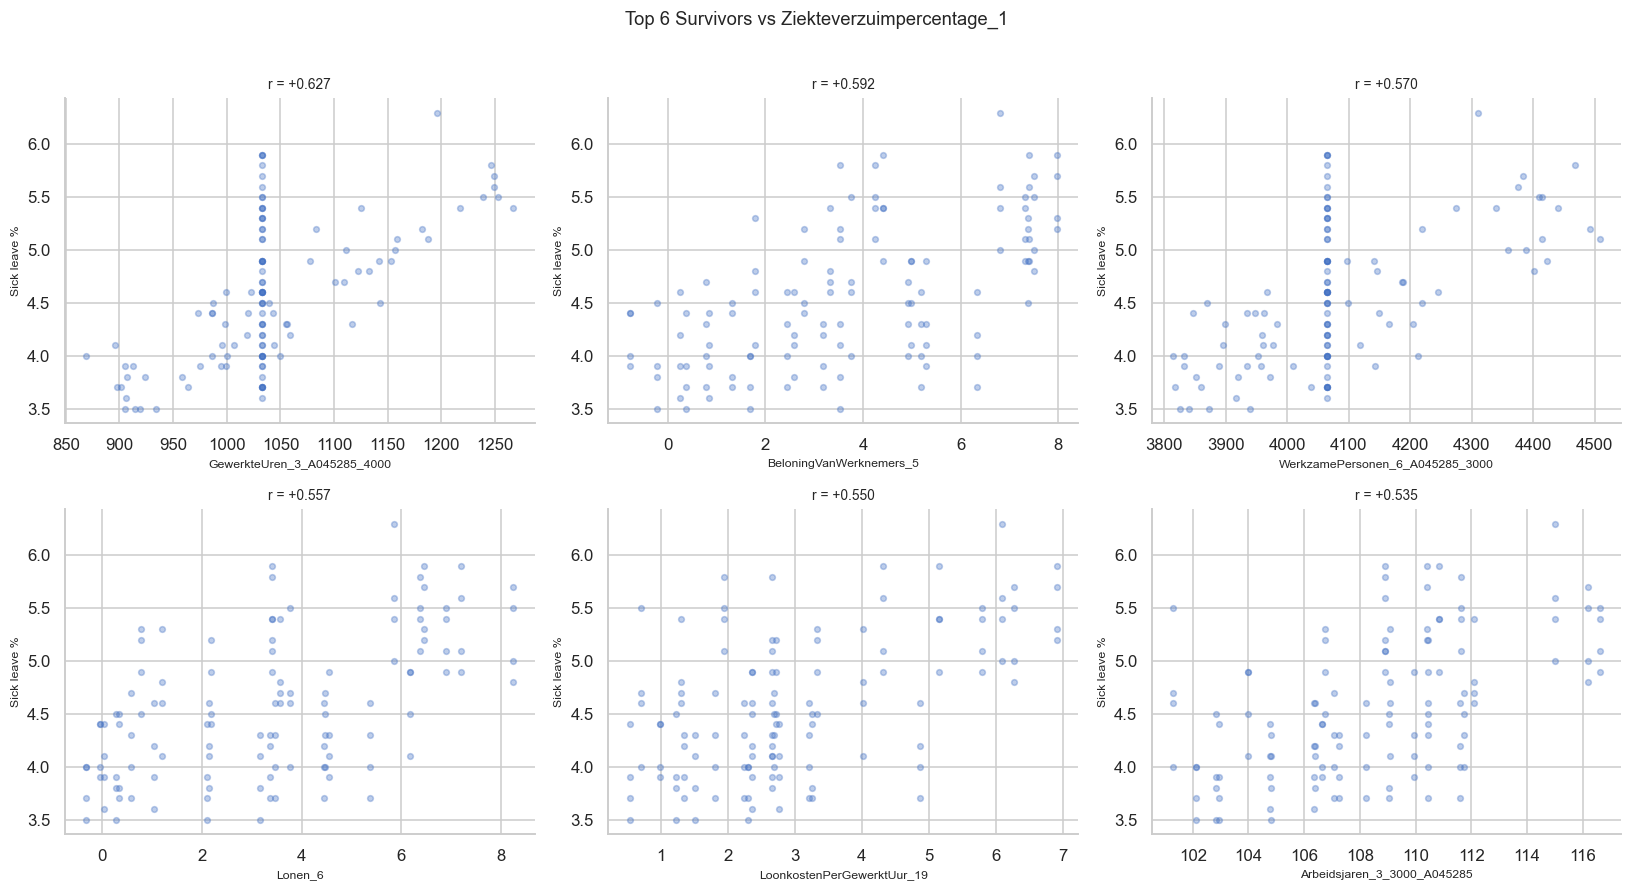

In [52]:
SCATTER_TOP_N = 6   # ← adjust this

_corr_rank = (
    df_raw[features_in_scope]
    .corrwith(df_raw[ML_TARGET_COLUMN])
    .dropna()
    .abs()
    .sort_values(ascending=False)
)
top_features = _corr_rank.head(SCATTER_TOP_N).index.tolist()

ncols = 3
nrows = (len(top_features) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for ax, feat in zip(axes, top_features):
    r = df_raw[feat].corr(df_raw[ML_TARGET_COLUMN])
    ax.scatter(df_raw[feat], df_raw[ML_TARGET_COLUMN],
               alpha=0.35, s=14, color=RETAINED_COLOR)
    ax.set_xlabel(feat[:45], fontsize=8)
    ax.set_ylabel("Sick leave %", fontsize=8)
    ax.set_title(f"r = {r:+.3f}", fontsize=9)
    sns.despine(ax=ax)

for ax in axes[len(top_features):]:
    ax.set_visible(False)

plt.suptitle(f"Top {len(top_features)} Survivors vs {ML_TARGET_COLUMN}", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 6 — Feature Group Assignment

Manually assign surviving features to named groups. These groups map directly to
`FEATURE_CATALOG` entries in `src/ml_engineering/model_configs.py`.

**Edit `PROPOSED_GROUPS` below, then run Section 8 to generate the ready-to-paste code.**

In [53]:
# ── EDIT THIS CELL ──────────────────────────────────────────────────────────
PROPOSED_GROUPS = {
    "compensation": {
        "columns": [
            "BeloningVanWerknemers_5",
            "BeloningPerArbeidsjaar_14",
            "BeloningPerGewerktUur_17",
            "Lonen_6",
            "LonenPerArbeidsjaar_15",
            "LonenPerGewerktUur_18",
            "LoonkostenPerArbeidsjaar_16",
            "LoonkostenPerGewerktUur_19",
        ],
        "source_table": "83415NED",
        "description": "Wage and labour cost indicators per worker, per hour and in total.",
    },
    "labor_volume": {
        "columns": [
            "Arbeidsjaren_3_3000_A045285",
            "BetaaldeOverwerkuren_24",
            "GewerkteUren_26",
            "GewerkteUren_3_A045285_4000",
            "GewerkteUren_4_3000_A045286",
            "GewerkteUren_5_A045285",
            "GewerkteUren_5_A045286",
            "GewerkteUrenPerWerkzamePersoon_4_A045286_4000",
            "GewerkteUrenPerWerkzamePersoon_9_A045285_3000",
            "GewerkteUrenPerWerkzamePersoon_9_A045286_3000",
            "GewerkteUrenPerWerkzamePersoon_9_A045286_4000",
        ],
        "source_table": "83415NED",
        "description": "Hours worked and overtime by sector and employee category.",
    },
    "workforce": {
        "columns": [
            "Totaal_36",
            "Vrouwen_32",
            "WerkzamePersonen_6_A045285_3000",
            "WerkzamePersonen_7_A045285",
            "WerkzamePersonen_7_A045286",
            "WerkzamePersonenSeizoengecorrigeerd_9_A045285",
            "WerkzamePersonenSeizoengecorrigeerd_9_A045286",
        ],
        "source_table": "83415NED",
        "description": "Number of employed persons, seasonally adjusted, by gender and category.",
    },
    "working_conditions": {
        "columns": [
            "GeenRepeterendeBewegingTijdensWerk_33_MBG0095",
            "LichamelijkGeweld_76_MOG0095",
        ],
        "source_table": "83157NED",
        "description": "NEA survey indicators: repetitive movement absence and physical violence at work.",
    },
}
# ── END EDIT ────────────────────────────────────────────────────────────────

assigned         = {col for g in PROPOSED_GROUPS.values() for col in g["columns"]}
unassigned       = [c for c in features_in_scope if c not in assigned]
unknown_assigned = [c for c in assigned if c not in features_in_scope]

print(f"Surviving features   : {len(features_in_scope)}")
print(f"Assigned to groups   : {len(assigned)}")
print(f"Unassigned survivors : {len(unassigned)}")

if unassigned:
    print("\n\u2500\u2500 Unassigned features \u2500\u2500")
    for c in sorted(unassigned):
        r = df_raw[c].corr(df_raw[ML_TARGET_COLUMN])
        print(f"  {c:60s}  r={r:+.3f}")

if unknown_assigned:
    print("\n\u26a0\ufe0f  Columns in PROPOSED_GROUPS not in surviving features:")
    for c in sorted(unknown_assigned):
        print(f"  {c}")

Surviving features   : 14
Assigned to groups   : 28
Unassigned survivors : 2

── Unassigned features ──
  GewerkteUren_3_A045286_4000                                   r=+0.470
  Mannen_31                                                     r=+0.480

⚠️  Columns in PROPOSED_GROUPS not in surviving features:
  BetaaldeOverwerkuren_24
  GeenRepeterendeBewegingTijdensWerk_33_MBG0095
  GewerkteUrenPerWerkzamePersoon_4_A045286_4000
  GewerkteUrenPerWerkzamePersoon_9_A045286_3000
  GewerkteUrenPerWerkzamePersoon_9_A045286_4000
  GewerkteUren_26
  GewerkteUren_4_3000_A045286
  GewerkteUren_5_A045286
  LichamelijkGeweld_76_MOG0095
  LonenPerArbeidsjaar_15
  LonenPerGewerktUur_18
  Vrouwen_32
  WerkzamePersonenSeizoengecorrigeerd_9_A045285
  WerkzamePersonenSeizoengecorrigeerd_9_A045286
  WerkzamePersonen_7_A045285
  WerkzamePersonen_7_A045286


---
## 7 — Reduction Summary

Funnel chart built from `filter_log` showing how many features survived each active filter,
followed by the final ranked feature list with target-correlation scores.

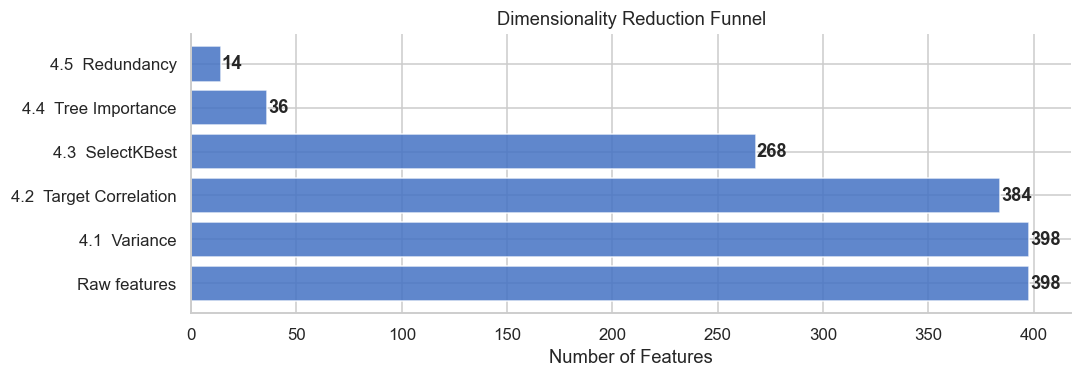


Final feature set: 14 features

  1. GewerkteUren_3_A045285_4000                                   r=+0.627
  2. BeloningVanWerknemers_5                                       r=+0.592
  3. WerkzamePersonen_6_A045285_3000                               r=+0.570
  4. Lonen_6                                                       r=+0.557
  5. LoonkostenPerGewerktUur_19                                    r=+0.550
  6. Arbeidsjaren_3_3000_A045285                                   r=+0.535
  7. BeloningPerArbeidsjaar_14                                     r=+0.508
  8. LoonkostenPerArbeidsjaar_16                                   r=+0.487
  9. Mannen_31                                                     r=+0.480
 10. GewerkteUren_3_A045286_4000                                   r=+0.470
 11. GewerkteUrenPerWerkzamePersoon_9_A045285_3000                 r=-0.457
 12. BeloningPerGewerktUur_17                                      r=+0.449
 13. Totaal_36                                         

In [54]:
steps = [("Raw features", len(feature_cols))] + [
    (r["filter"], len(r["retained"])) for r in filter_log
]
labels, counts = zip(*steps)

fig, ax = plt.subplots(figsize=(10, max(3.5, len(steps) * 0.6)))
bars = ax.barh(range(len(labels)), counts, color=RETAINED_COLOR, edgecolor="white", alpha=0.85)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel("Number of Features")
ax.set_title("Dimensionality Reduction Funnel")
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            str(count), va="center", fontweight="bold")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

final_corr = (
    df_raw[features_in_scope]
    .corrwith(df_raw[ML_TARGET_COLUMN])
    .dropna()
    .sort_values(key=abs, ascending=False)
)
print(f"\nFinal feature set: {len(features_in_scope)} features\n")
for i, (col, r) in enumerate(final_corr.items(), 1):
    print(f"{i:>3}. {col:60s}  r={r:+.3f}")

---
## 8 — Generate FEATURE_CATALOG

Run after completing Section 6. Prints ready-to-paste Python code for
`FEATURE_CATALOG` in `src/ml_engineering/model_configs.py`.

In [55]:
def _fmt_list(cols, indent=12):
    if not cols:
        return "[]"
    pad   = " " * indent
    sep   = ",\n" + pad
    inner = sep.join(f'"{c}"' for c in cols)
    tail  = " " * (indent - 4)
    return f"[\n{pad}{inner},\n{tail}]"


lines = ["FEATURE_CATALOG: Dict[str, FeatureGroup] = {"]
for group_name, meta in PROPOSED_GROUPS.items():
    lines += [
        f'    "{group_name}": FeatureGroup(',
        f'        name="{group_name}",',
        f'        columns={_fmt_list(meta["columns"])},',
        f'        source_table="{meta["source_table"]}",',
        f'        description="{meta["description"]}",',
        f'    ),',
    ]
lines.append("}")

print("=" * 70)
print("Paste the following into model_configs.py (replace FEATURE_CATALOG):")
print("=" * 70)
print("\n".join(lines))

Paste the following into model_configs.py (replace FEATURE_CATALOG):
FEATURE_CATALOG: Dict[str, FeatureGroup] = {
    "compensation": FeatureGroup(
        name="compensation",
        columns=[
            "BeloningVanWerknemers_5",
            "BeloningPerArbeidsjaar_14",
            "BeloningPerGewerktUur_17",
            "Lonen_6",
            "LonenPerArbeidsjaar_15",
            "LonenPerGewerktUur_18",
            "LoonkostenPerArbeidsjaar_16",
            "LoonkostenPerGewerktUur_19",
        ],
        source_table="83415NED",
        description="Wage and labour cost indicators per worker, per hour and in total.",
    ),
    "labor_volume": FeatureGroup(
        name="labor_volume",
        columns=[
            "Arbeidsjaren_3_3000_A045285",
            "BetaaldeOverwerkuren_24",
            "GewerkteUren_26",
            "GewerkteUren_3_A045285_4000",
            "GewerkteUren_4_3000_A045286",
            "GewerkteUren_5_A045285",
            "GewerkteUren_5_A045286",
     